In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)

try:
    gdp_region_df = gdp_with_region.copy()
    print("Using existing variable: gdp_with_region")
except NameError:
    gdp_region_df = pd.read_csv("/Users/tonytony/Final Project/Data/Cleaned/gdp_with_wb_region.csv")
    print("Loaded file: gdp_with_wb_region.csv")

print("Shape:", gdp_region_df.shape)
gdp_region_df.head()


Loaded file: gdp_with_wb_region.csv
Shape: (266, 75)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2021,2022,2023,2024,Unnamed: 69,WB Region,Admin Region,Income Level,Lending Type,Country Type
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,26749.329609,30975.998912,35718.753119,39498.594129,NaN,Latin America & Caribbean,NaN,High income,Not classified,Country/Territory
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1562.416175,1679.327622,1571.449189,1615.396356,NaN,Aggregates,NaN,Aggregates,Aggregates,Aggregate
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,356.496214,357.261153,413.757895,NaN,NaN,"Middle East, North Africa, Afghanistan & Pakistan","Middle East, North Africa, Afghanistan & Pakis...",Low income,IDA,Country/Territory
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,2112.794076,2138.473153,1841.855064,1411.337029,NaN,Aggregates,NaN,Aggregates,Aggregates,Aggregate
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2303.908127,3682.113151,2916.136633,2665.874448,NaN,Sub-Saharan Africa,Sub-Saharan Africa (excluding high income),Lower middle income,IBRD,Country/Territory


In [3]:
if "Country Type" not in gdp_region_df.columns:
    gdp_region_df["Country Type"] = gdp_region_df["WB Region"].apply(
        lambda x: "Aggregate" if str(x).strip() == "Aggregates" else "Country/Territory"
    )

year_cols = [col for col in gdp_region_df.columns if str(col).isdigit()]
gdp_region_df[year_cols] = gdp_region_df[year_cols].apply(pd.to_numeric, errors="coerce")

gdp_long = gdp_region_df.melt(
    id_vars=["Country Name", "Country Code", "WB Region", "Country Type"],
    value_vars=year_cols,
    var_name="Year",
    value_name="GDP per capita (current US$)"
)

gdp_long["Year"] = pd.to_numeric(gdp_long["Year"], errors="coerce").astype("Int64")
gdp_long["GDP per capita (current US$)"] = pd.to_numeric(
    gdp_long["GDP per capita (current US$)"],
    errors="coerce"
)

gdp_long = gdp_long[
    (gdp_long["Country Type"] == "Country/Territory") &
    (gdp_long["WB Region"].notna()) &
    (gdp_long["GDP per capita (current US$)"].notna()) &
    (gdp_long["GDP per capita (current US$)"] > 0)
].copy()

print("Long-format GDP dataset shape:", gdp_long.shape)
print("Year range:", int(gdp_long["Year"].min()), "-", int(gdp_long["Year"].max()))
print("Number of countries/territories:", gdp_long["Country Code"].nunique())

gdp_long.head()


Long-format GDP dataset shape: (11569, 6)
Year range: 1960 - 2024
Number of countries/territories: 214


,Country Name,Country Code,WB Region,Country Type,Year,GDP per capita (current US$)
9,Argentina,ARG,Latin America & Caribbean,Country/Territory,1960,778.251707
13,Australia,AUS,East Asia & Pacific,Country/Territory,1960,1813.431099
14,Austria,AUT,Europe & Central Asia,Country/Territory,1960,939.914815
16,Burundi,BDI,Sub-Saharan Africa,Country/Territory,1960,70.905100
17,Belgium,BEL,Europe & Central Asia,Country/Territory,1960,1290.286072


In [4]:
gdp_global_trend = (
    gdp_long
    .groupby("Year")
    .agg(
        country_count=("Country Code", "nunique"),
        mean_gdp_per_capita=("GDP per capita (current US$)", "mean"),
        median_gdp_per_capita=("GDP per capita (current US$)", "median"),
        min_gdp_per_capita=("GDP per capita (current US$)", "min"),
        max_gdp_per_capita=("GDP per capita (current US$)", "max")
    )
    .reset_index()
)

gdp_region_trend = (
    gdp_long
    .groupby(["WB Region", "Year"])
    .agg(
        country_count=("Country Code", "nunique"),
        mean_gdp_per_capita=("GDP per capita (current US$)", "mean"),
        median_gdp_per_capita=("GDP per capita (current US$)", "median"),
        min_gdp_per_capita=("GDP per capita (current US$)", "min"),
        max_gdp_per_capita=("GDP per capita (current US$)", "max")
    )
    .reset_index()
    .sort_values(["WB Region", "Year"])
)

print("Global trend shape:", gdp_global_trend.shape)
print("Regional trend shape:", gdp_region_trend.shape)

gdp_global_trend.head()


Global trend shape: (65, 6)
Regional trend shape: (455, 7)


,Year,country_count,mean_gdp_per_capita,median_gdp_per_capita,min_gdp_per_capita,max_gdp_per_capita
0,1960,111,507.723857,256.813115,25.084776,2999.864872
1,1961,113,529.999973,270.279647,27.265454,3059.160821
2,1962,115,586.628629,265.210652,27.947004,4748.392844
3,1963,115,621.332739,288.820390,25.803984,4444.523086
4,1964,115,673.737824,284.197970,17.332201,4378.784298


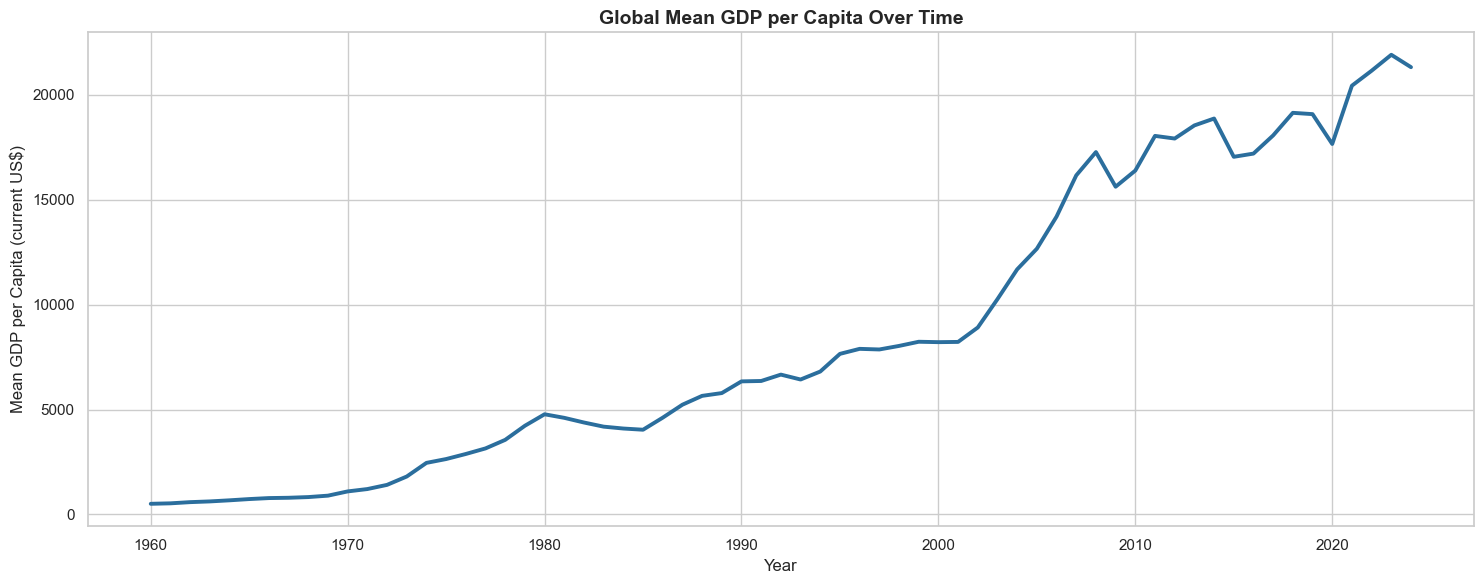

In [7]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=gdp_global_trend,
    x="Year",
    y="mean_gdp_per_capita",
    linewidth=2.8,
    color="#2B6E9D"
)

plt.title("Global Mean GDP per Capita Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Mean GDP per Capita (current US$)")
plt.tight_layout()
plt.show()


### Insight - Global Mean GDP per Capita

The chart shows the long-term trend of average GDP per capita across countries.

Key observations:
- The overall trend is generally upward over time, suggesting that average income per person has increased globally.
- The line may show periods of slower growth or temporary decline, which can reflect global economic shocks.
- Because the chart uses the **mean**, it is likely influenced by high-income countries with very large GDP per capita values.

Conclusion:
The global mean GDP per capita suggests broad long-term improvement, but the average may overstate the typical country because GDP per capita is strongly affected by high-value economies.


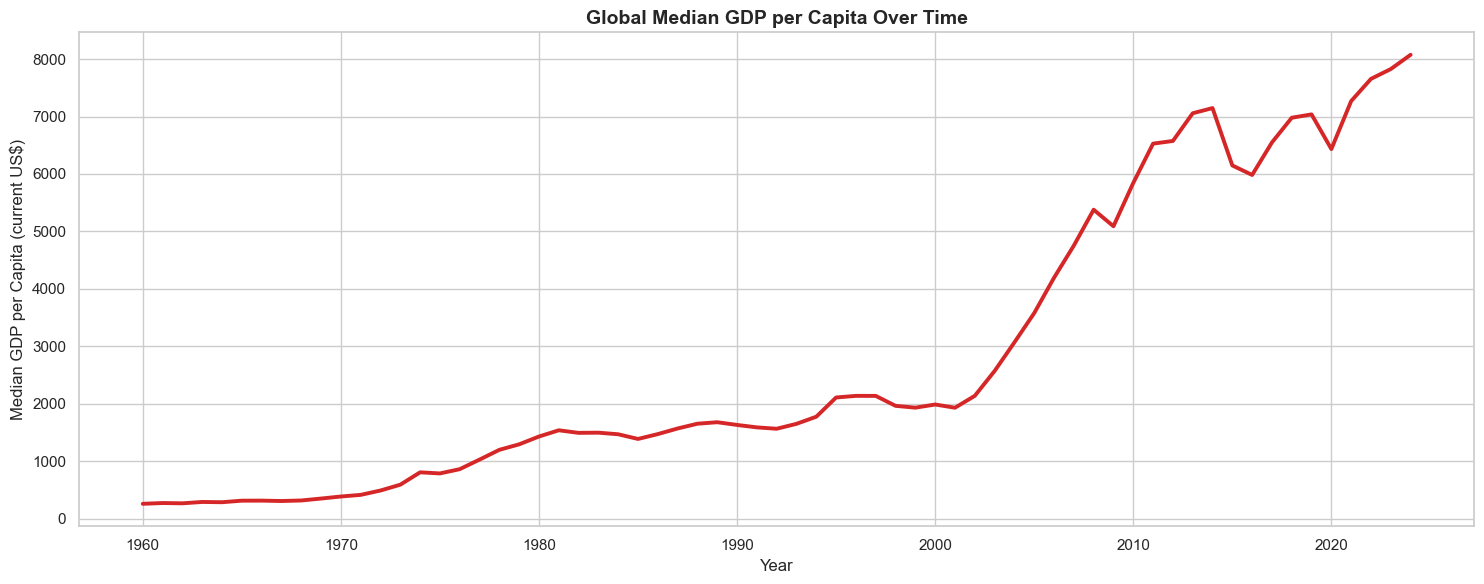

In [8]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=gdp_global_trend,
    x="Year",
    y="median_gdp_per_capita",
    linewidth=2.8,
    color="#d62728"
)

plt.title("Global Median GDP per Capita Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Median GDP per Capita (current US$)")
plt.tight_layout()
plt.show()


### Insight - Global Median GDP per Capita

The median line reflects the middle country rather than the overall average.

Key observations:
- The median also tends to rise over time, which suggests that GDP per capita has improved for the typical country as well.
- If the median is much lower than the mean, this indicates that the distribution is right-skewed.
- Comparing this chart with the mean chart helps identify whether global GDP patterns are driven by a few very rich countries.

Conclusion:
The median confirms a long-term upward trend, but it also highlights that global income gains are not distributed evenly across countries.


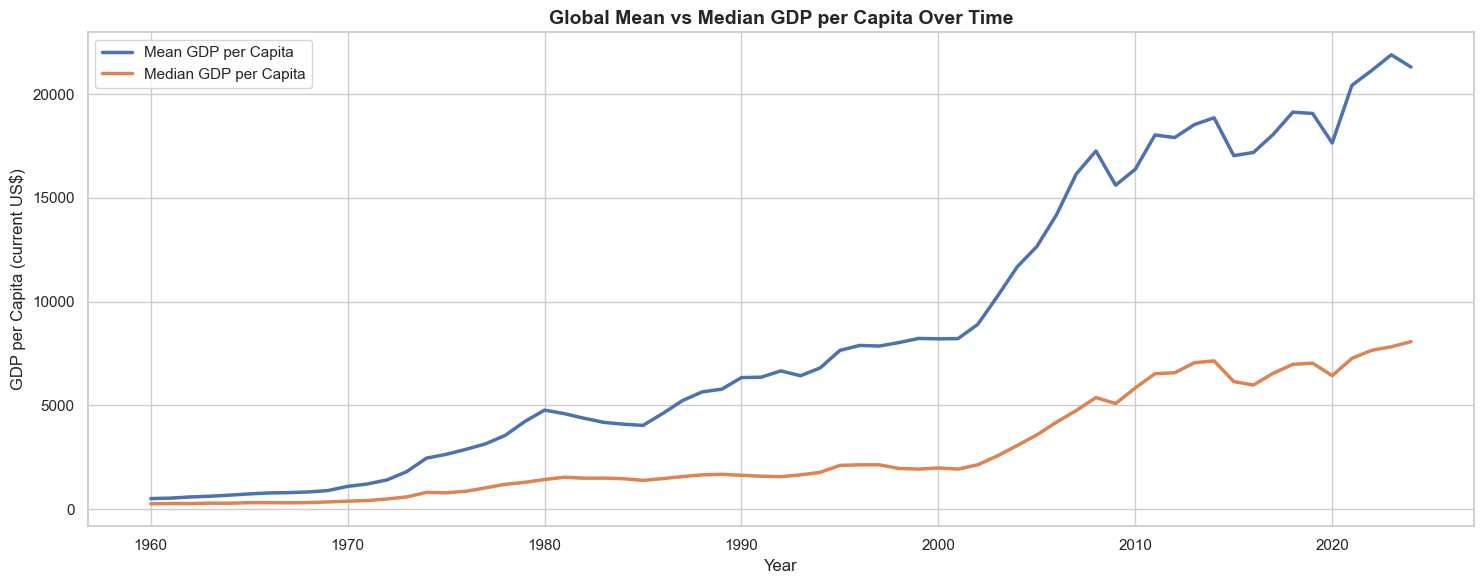

In [9]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=gdp_global_trend,
    x="Year",
    y="mean_gdp_per_capita",
    linewidth=2.5,
    label="Mean GDP per Capita"
)

sns.lineplot(
    data=gdp_global_trend,
    x="Year",
    y="median_gdp_per_capita",
    linewidth=2.5,
    label="Median GDP per Capita"
)

plt.title("Global Mean vs Median GDP per Capita Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("GDP per Capita (current US$)")
plt.legend()
plt.tight_layout()
plt.show()


### Insight - Mean vs Median GDP per Capita

This chart is useful for understanding the distribution of GDP per capita.

Key observations:
- The mean line is generally above the median line.
- This suggests that GDP per capita is right-skewed, meaning a small number of high-income countries pull the average upward.
- The consistent gap between the two lines indicates that inequality in country-level GDP per capita remains significant over time.

Conclusion:
The difference between mean and median shows that GDP per capita is not evenly distributed across countries, so both measures should be used when interpreting trends.


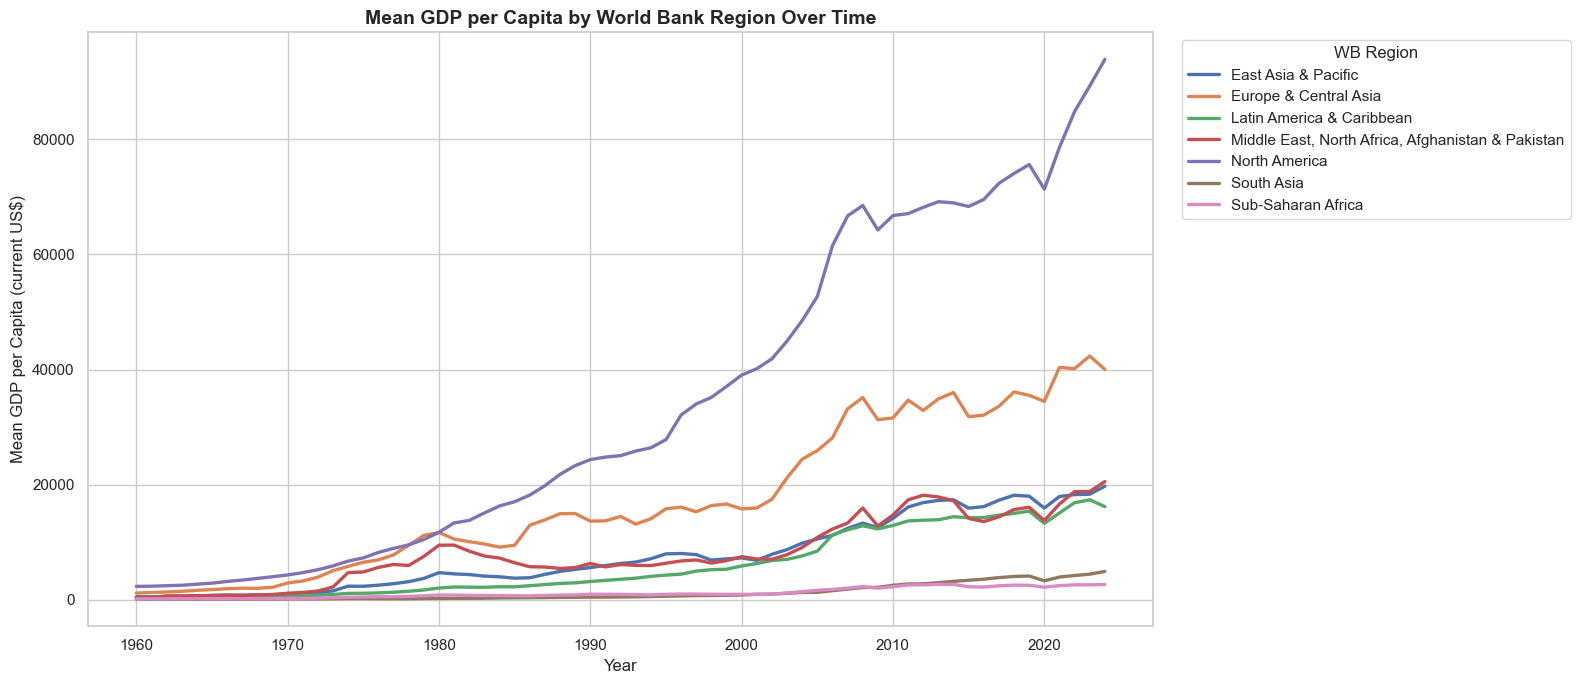

In [10]:
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=gdp_region_trend,
    x="Year",
    y="mean_gdp_per_capita",
    hue="WB Region",
    linewidth=2.4
)

plt.title("Mean GDP per Capita by World Bank Region Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Mean GDP per Capita (current US$)")
plt.legend(title="WB Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight - Mean GDP per Capita by World Bank Region

This chart shows strong differences in average GDP per capita across regions.

Key observations:
- Some regions remain consistently above others, indicating persistent differences in economic development.
- Higher-income regions tend to have much higher GDP per capita throughout the entire period.
- Lower-income regions may also improve over time, but often remain far below the highest-income groups.
- The gaps between regions suggest that economic growth has not been evenly distributed worldwide.

Conclusion:
Regional inequality in GDP per capita remains substantial. Even if most regions show upward movement, the distance between high-income and low-income regions is still large.


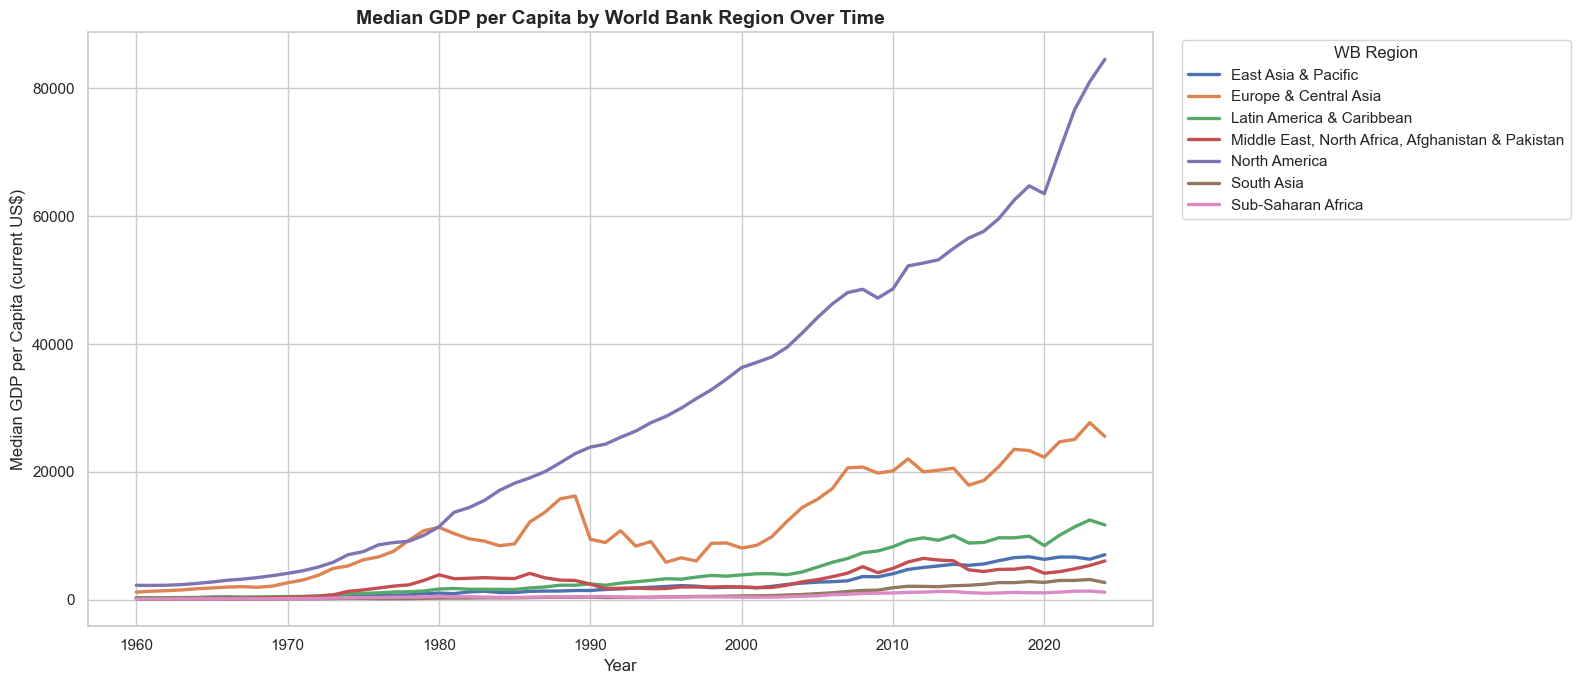

In [11]:
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=gdp_region_trend,
    x="Year",
    y="median_gdp_per_capita",
    hue="WB Region",
    linewidth=2.4
)

plt.title("Median GDP per Capita by World Bank Region Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Median GDP per Capita (current US$)")
plt.legend(title="WB Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight - Median GDP per Capita by World Bank Region

This chart provides a more typical view of GDP per capita within each region.

Key observations:
- Median values are often lower than mean values, which suggests that some regions are affected by a few high-income economies.
- The relative position of regions may remain similar, but the gaps are often less extreme than in the mean chart.
- This chart is useful for identifying the economic level of the typical country in each region.

Conclusion:
The median chart confirms regional differences while reducing the effect of outliers. It is therefore a more stable measure for comparing typical GDP conditions across regions.


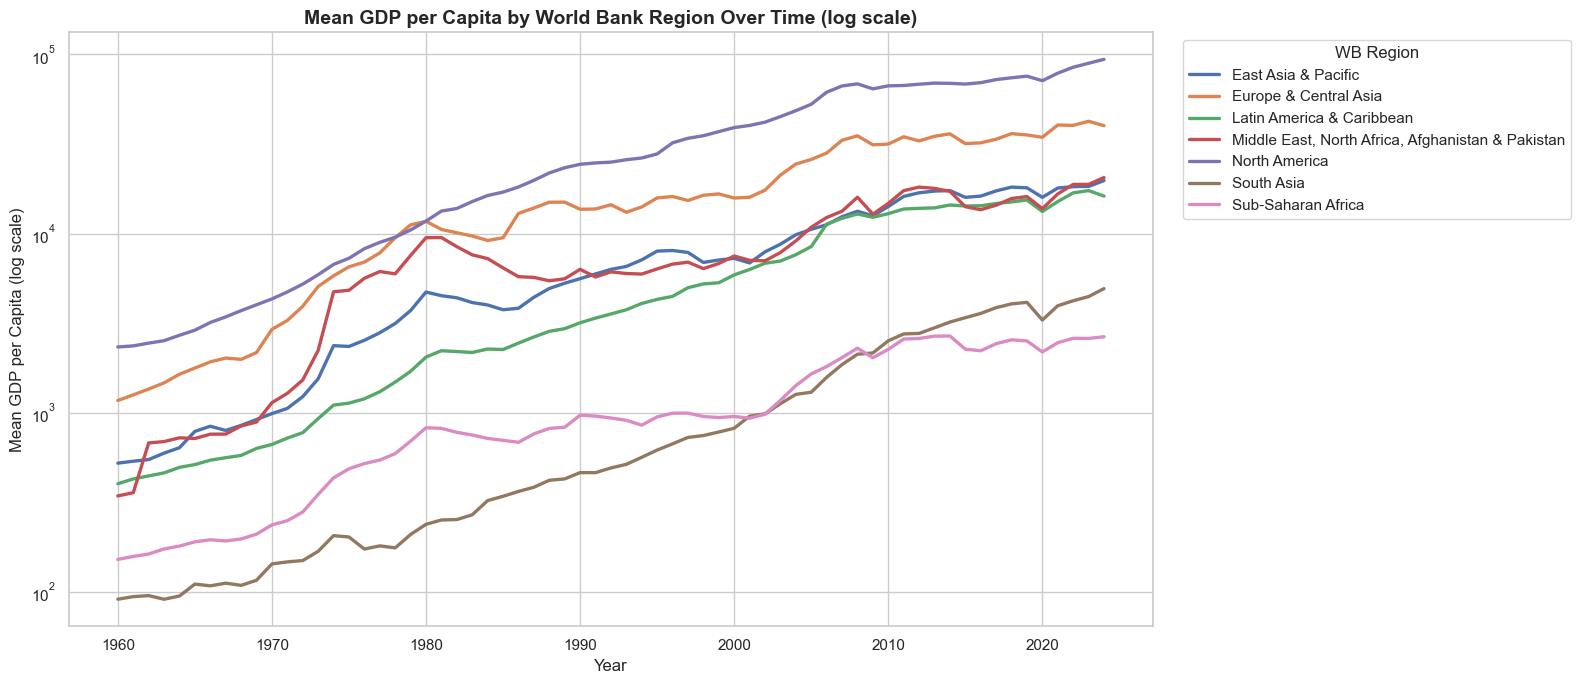

In [12]:
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=gdp_region_trend,
    x="Year",
    y="mean_gdp_per_capita",
    hue="WB Region",
    linewidth=2.4
)

plt.yscale("log")
plt.title("Mean GDP per Capita by World Bank Region Over Time (log scale)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Mean GDP per Capita (log scale)")
plt.legend(title="WB Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight - Mean GDP per Capita by Region (log scale)

The log-scale version makes it easier to observe relative differences between regions.

Key observations:
- Lower-income regions become more visible because the scale reduces the dominance of very high-income regions.
- Relative growth patterns can be seen more clearly across all regions.
- This chart is especially helpful when the standard scale compresses lower-value regions too much.

Conclusion:
The log-scale chart improves interpretability and helps compare long-term relative changes in GDP per capita across regions.


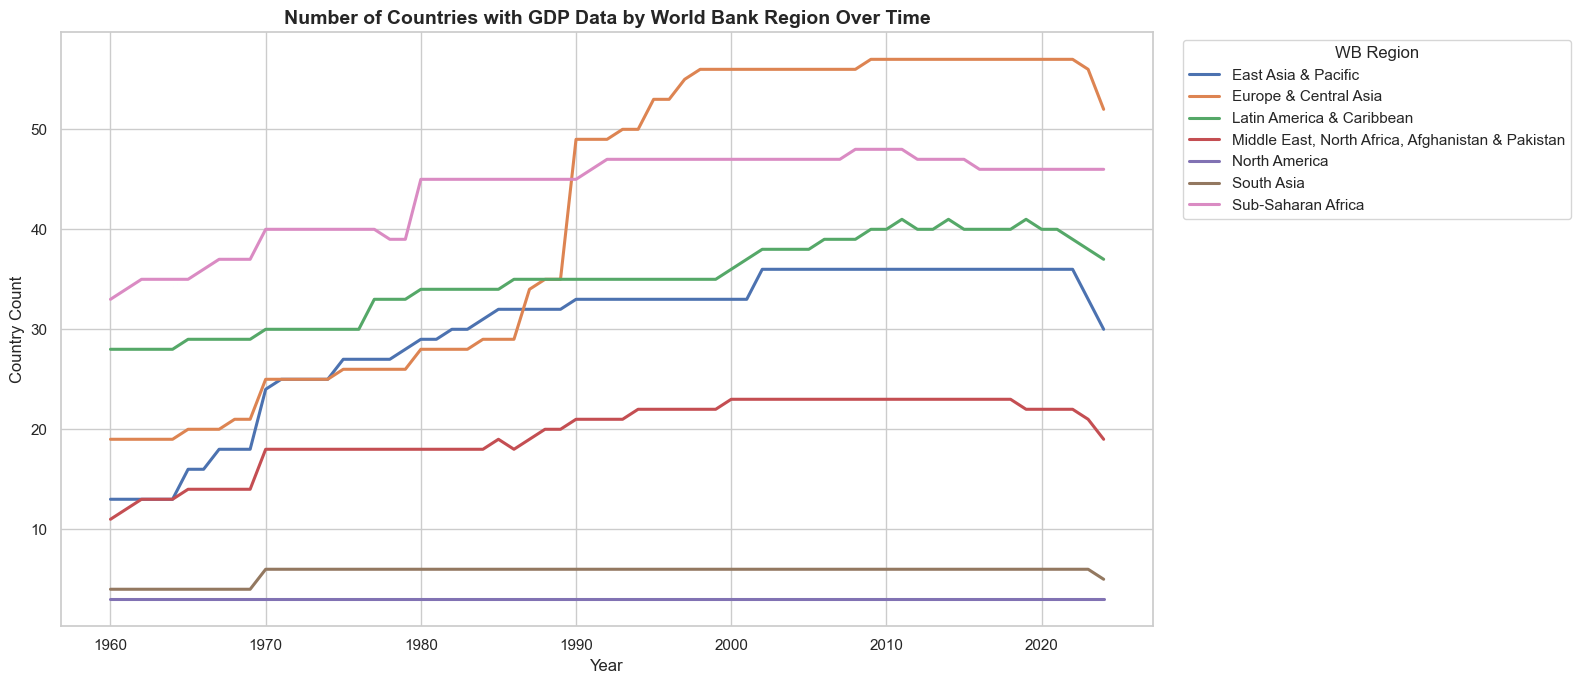

In [13]:
plt.figure(figsize=(16, 7))

sns.lineplot(
    data=gdp_region_trend,
    x="Year",
    y="country_count",
    hue="WB Region",
    linewidth=2.2
)

plt.title("Number of Countries with GDP Data by World Bank Region Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Country Count")
plt.legend(title="WB Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight - Data Coverage by Region

This chart helps evaluate the reliability of the time-series comparison.

Key observations:
- Data availability may be lower in earlier years.
- Some regions may have more complete coverage than others.
- The most recent year may not always contain data for all countries.

Conclusion:
Changes in country coverage should be considered when interpreting regional GDP trends, especially in the earliest and latest parts of the time series.


In [14]:
latest_year = int(gdp_region_trend["Year"].max())

gdp_latest_region = (
    gdp_region_trend[gdp_region_trend["Year"] == latest_year]
    .sort_values("mean_gdp_per_capita", ascending=False)
    .reset_index(drop=True)
)

print("Latest year:", latest_year)
gdp_latest_region


Latest year: 2024


,WB Region,Year,country_count,mean_gdp_per_capita,median_gdp_per_capita,min_gdp_per_capita,max_gdp_per_capita
0,North America,2024,3,93909.921073,84534.040784,54340.347722,142855.374714
1,Europe & Central Asia,2024,52,40036.868006,25548.120256,1341.202290,288001.433369
2,"Middle East, North Africa, Afghanistan & Pakistan",2024,19,20542.962032,6073.610323,1478.772780,76688.694174
3,East Asia & Pacific,2024,30,19746.665958,7048.625169,1331.970513,90674.066633
4,Latin America & Caribbean,2024,37,16186.775284,11705.090298,2142.623305,41472.587450
5,South Asia,2024,5,4926.076640,2694.737809,1447.310045,13379.351358
6,Sub-Saharan Africa,2024,46,2653.074792,1186.913176,219.424831,17858.822638


In [15]:
highest_region = gdp_latest_region.iloc[0]
lowest_region = gdp_latest_region.iloc[-1]

print(f"Latest year in the dataset: {latest_year}")
print(f"Highest mean GDP per capita region: {highest_region['WB Region']} ({highest_region['mean_gdp_per_capita']:,.2f} US$)")
print(f"Lowest mean GDP per capita region: {lowest_region['WB Region']} ({lowest_region['mean_gdp_per_capita']:,.2f} US$)")
print("Interpretation note: median should be used together with mean because GDP per capita is usually right-skewed and influenced by high-value countries.")


Latest year in the dataset: 2024
Highest mean GDP per capita region: North America (93,909.92 US$)
Lowest mean GDP per capita region: Sub-Saharan Africa  (2,653.07 US$)
Interpretation note: median should be used together with mean because GDP per capita is usually right-skewed and influenced by high-value countries.
